# Assignment 10
Darsh SA - MS22068

## Question 1
Training YOLOv8 on the VOC2012 dataset

The dataset is installed using the ultralytics package using the voc.yaml file used for configuration of the dataset

In [12]:
import cv2
from ultralytics import YOLO

%matplotlib inline

In [2]:
model = YOLO("Machine_Learning/Ass10/yolov8n.pt")

results = model.train(data="VOC.yaml", epochs=25, imgsz=640, fraction=0.25)

New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650, 3718MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VOC.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.25, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=Machine_Learning/Ass10/yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, na

### Explaining the Results:

The training used the following args (stored in [args.yaml]() file) :
- Epochs = 25
- Fraction = 0.25 (only using 25% of the dataset)
- batch = 16
- patience = 100
- imgsz = 640

Other args just defaults

The training was done on a GTX 1650 with 16GB of ram (which was sadly not enough for caching to be used ;-;)



##### Confidence Scores

1. **Precision-Confidence:** Measures Quality: "Out of all the boxes the model actually drew, how many were correct?"
    * As confidence increases, precision goes up (the model gets pickier and makes fewer false-positive mistakes).

2. **Recall-Confidence:** Measures Quantity: "Out of all the actual objects hidden in the images, how many did the model find?"
    * As confidence increases, recall goes down (the model becomes too strict and misses real objects).

3. **F1-Confidence:** Balances Precision and Recall into a single score
    * It forms an arch, peaking at 0.474 confidence, which is the optimal threshold.

4. **Precision-Recall (PR):** plots Quality against Quantity to show the overall trade-off.
    * It slopes downward a curve that stays high and pushed toward the top-right corner indicates a better model

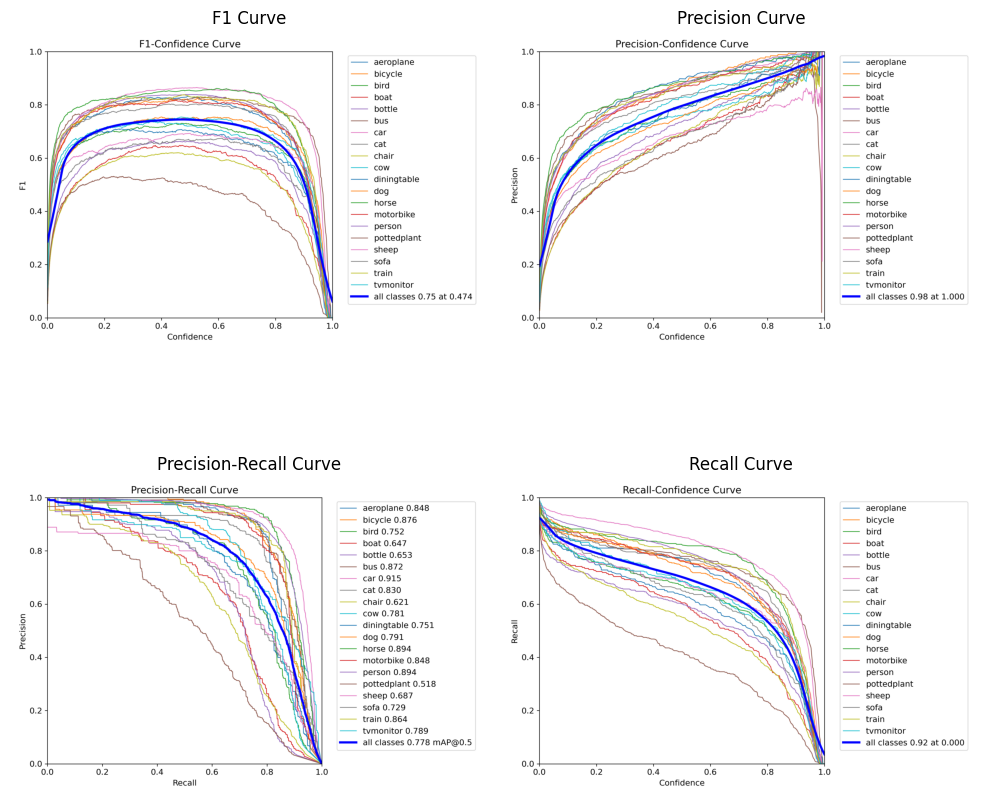

In [13]:
import matplotlib.pyplot as plt

plt.close('all')

paths = [
    ("F1 Curve", "results/BoxF1_curve.png"),
    ("Precision Curve", "results/BoxP_curve.png"),
    ("Precision-Recall Curve", "results/BoxPR_curve.png"),
    ("Recall Curve", "results/BoxR_curve.png"),
]

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for ax, (title, path) in zip(axs.ravel(), paths):
    img = plt.imread(path)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

#### Confusion Matrix

The matrix looks perfect except for some few exceptions for false positives as we used only 25% of the dataset this is accepted.

We also see the dataset contains way more data of people and car, even after this it balances out the overfitting as seen from the confidence scores

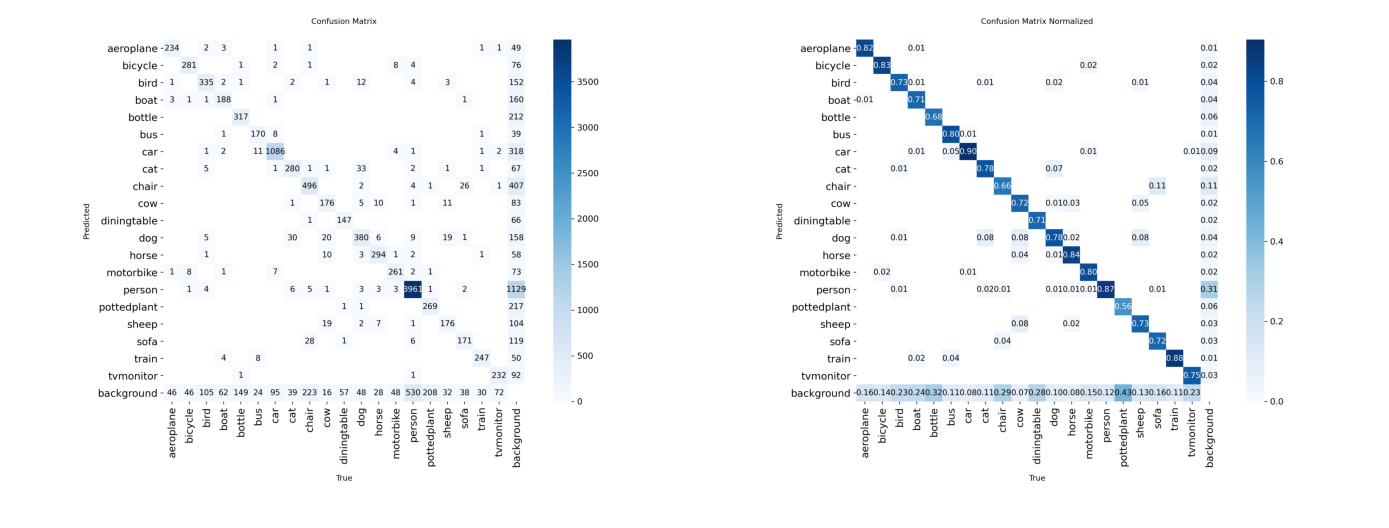

In [18]:
conf_matrix = plt.imread("results/confusion_matrix.png")
conf_matrix_norm = plt.imread("results/confusion_matrix_normalized.png")

fig, axs = plt.subplots(1, 2, figsize=(14, 8))
axs[0].imshow(conf_matrix)
axs[0].axis('off')

axs[1].imshow(conf_matrix_norm)
axs[1].axis('off')

plt.tight_layout()
plt.show()

#### Examples

Some results from the trained model

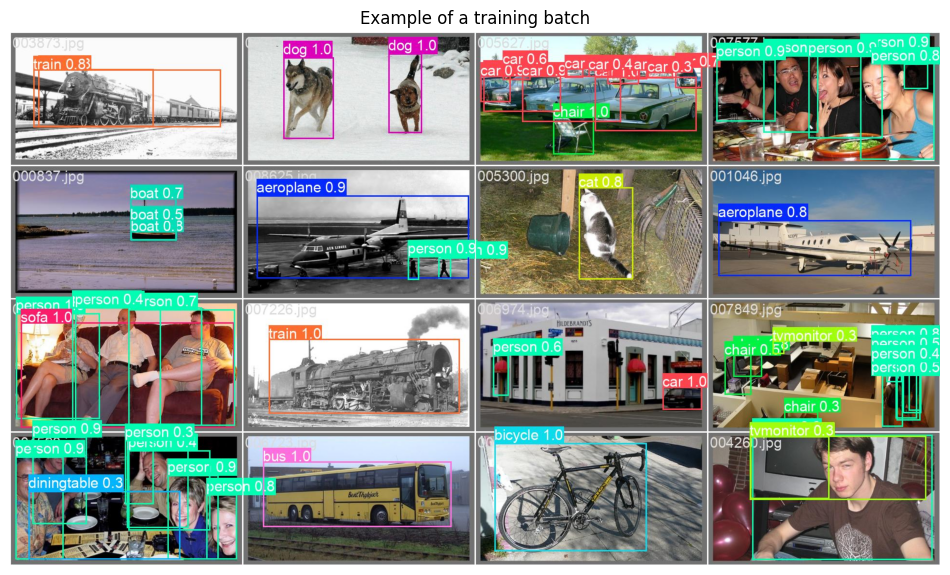

In [21]:
ex1 = plt.imread("results/val_batch2_pred.jpg")

plt.figure(figsize=(12, 12))
plt.imshow(ex1)
plt.axis('off')
plt.title("Example of a training batch")
plt.show()

---

## Question 2

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.utils import to_networkx
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/ardo/mlem/Study/Sem8/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


### Loading the MUTAG Dataset

MUTAG is a benchmark dataset of 188 nitroaromatic compounds. Each molecule is represented as a graph where nodes are atoms and edges are chemical bonds. The binary label indicates whether the compound has a mutagenic effect on the bacterium *Salmonella typhimurium* (1 = mutagenic, 0 = non-mutagenic).

In [ ]:
dataset = TUDataset(root="data/", name="MUTAG")

print(f"Dataset: {dataset}")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Number of node features: {dataset.num_node_features}")
print(f"Number of edge features: {dataset.num_edge_features}")

labels = [data.y.item() for data in dataset]
print(f"\nClass distribution:")
print(f"  Mutagenic (1): {labels.count(1)}")
print(f"  Non-mutagenic (0): {labels.count(0)}")

sample = dataset[0]
print(f"\nSample graph (index 0):")
print(f"  Nodes: {sample.num_nodes}, Edges: {sample.num_edges}")
print(f"  Node feature shape: {sample.x.shape}")
print(f"  Edge index shape: {sample.edge_index.shape}")
print(f"  Label: {sample.y.item()}")

Dataset: MUTAG(188)
Number of graphs: 188
Number of classes: 2
Number of node features: 7
Number of edge features: 4

Class distribution:
  Mutagenic (1):     125
  Non-mutagenic (0): 63

Sample graph (index 0):
  Nodes: 17, Edges: 38
  Node feature shape: torch.Size([17, 7])
  Edge index shape:   torch.Size([2, 38])
  Label: 1


### Visualizing Molecular Graphs

Node labels in MUTAG correspond to atom types: C, N, O, F, I, Cl, Br (one-hot encoded in the node features). We pick 2 mutagenic and 2 non-mutagenic molecules to visualize.

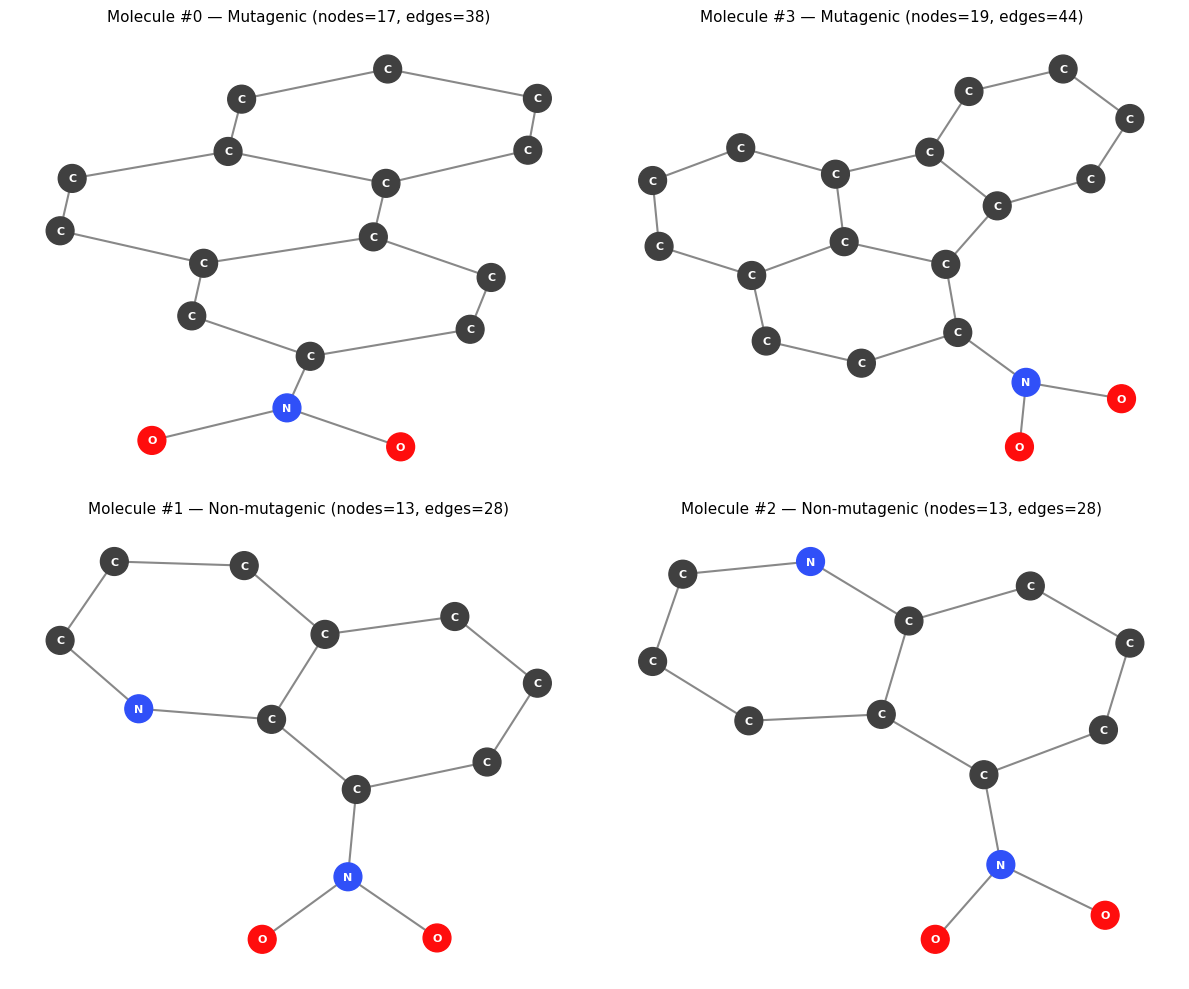

In [3]:
ATOM_LABELS = ["C", "N", "O", "F", "I", "Cl", "Br"]
ATOM_COLORS = {
    "C": "#404040", "N": "#3050F8", "O": "#FF0D0D",
    "F": "#90E050", "I": "#940094", "Cl": "#1FF01F", "Br": "#A62929",
}

def visualize_molecule(data, ax, title):
    G = to_networkx(data, to_undirected=True)
    atom_types = data.x.argmax(dim=1).numpy()
    node_labels = {i: ATOM_LABELS[t] for i, t in enumerate(atom_types)}
    node_colors = [ATOM_COLORS[ATOM_LABELS[t]] for t in atom_types]

    pos = nx.kamada_kawai_layout(G)
    nx.draw(
        G, pos, ax=ax,
        with_labels=True, labels=node_labels,
        node_color=node_colors, node_size=400,
        font_color="white", font_weight="bold", font_size=8,
        edge_color="#888888", width=1.5,
    )
    ax.set_title(title, fontsize=11)

mutagenic_idx = [i for i, d in enumerate(dataset) if d.y.item() == 1]
non_mutagenic_idx = [i for i, d in enumerate(dataset) if d.y.item() == 0]

selected = (
    mutagenic_idx[:2] + non_mutagenic_idx[:2]
)
class_names = {0: "Non-mutagenic", 1: "Mutagenic"}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, idx in zip(axes.flat, selected):
    data = dataset[idx]
    label = class_names[data.y.item()]
    visualize_molecule(data, ax, f"Molecule #{idx} — {label} (nodes={data.num_nodes}, edges={data.num_edges})")

plt.tight_layout()
plt.savefig("mutag_molecules.png", dpi=150, bbox_inches="tight")
plt.show()

### GNN Architecture — Graph Isomorphism Network (GIN)

We use a **GIN (Graph Isomorphism Network)**, which is as powerful as the Weisfeiler-Leman graph isomorphism test. GIN applies an MLP in each message-passing layer, making it more expressive than simple sum-based aggregation. We stack 3 GIN layers followed by global sum pooling and an MLP classifier.

In [4]:
class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.bns = torch.nn.ModuleList()
        self.dropout = dropout

        for i in range(num_layers):
            in_dim = in_channels if i == 0 else hidden_channels
            mlp = torch.nn.Sequential(
                torch.nn.Linear(in_dim, hidden_channels),
                torch.nn.BatchNorm1d(hidden_channels),
                torch.nn.ReLU(),
                torch.nn.Linear(hidden_channels, hidden_channels),
            )
            self.convs.append(GINConv(mlp, train_eps=True))
            self.bns.append(torch.nn.BatchNorm1d(hidden_channels))

        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_channels, out_channels),
        )

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, edge_index)))
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = global_add_pool(x, batch)
        return self.classifier(x)

model = GIN(
    in_channels=dataset.num_node_features,
    hidden_channels=64,
    out_channels=dataset.num_classes,
    num_layers=3,
    dropout=0.5,
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

GIN(
  (convs): ModuleList(
    (0): GINConv(nn=Sequential(
      (0): Linear(in_features=7, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=64, out_features=64, bias=True)
    ))
    (1-2): 2 x GINConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=64, out_features=64, bias=True)
    ))
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total parameters: 26,373


### Training with Stratified K-Fold Cross-Validation

We use 5-fold stratified cross-validation to get a robust accuracy estimate on this small dataset (188 graphs). Each fold trains for 100 epochs with the Adam optimizer.

In [5]:
def train(model, loader, optimizer):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = F.cross_entropy(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        total_loss += F.cross_entropy(out, data.y, reduction="sum").item()
        all_preds.extend(out.argmax(dim=1).cpu().numpy())
        all_labels.extend(data.y.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), acc, np.array(all_preds), np.array(all_labels)


EPOCHS = 100
K_FOLDS = 5
LR = 1e-3
BATCH_SIZE = 32

labels = np.array([data.y.item() for data in dataset])
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_results = []
all_train_losses = []
all_val_losses = []

for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(dataset)), labels)):
    train_data = [dataset[int(i)] for i in train_idx]
    test_data = [dataset[int(i)] for i in test_idx]

    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

    model = GIN(
        in_channels=dataset.num_node_features,
        hidden_channels=64,
        out_channels=dataset.num_classes,
        num_layers=3,
        dropout=0.5,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_losses, val_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        t_loss = train(model, train_loader, optimizer)
        v_loss, v_acc, _, _ = evaluate(model, test_loader)
        train_losses.append(t_loss)
        val_losses.append(v_loss)

    _, final_acc, preds, true_labels = evaluate(model, test_loader)
    fold_results.append({"fold": fold + 1, "acc": final_acc, "preds": preds, "labels": true_labels})
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

    print(f"Fold {fold+1}/{K_FOLDS} — Test Accuracy: {final_acc:.4f}")

mean_acc = np.mean([r["acc"] for r in fold_results])
std_acc = np.std([r["acc"] for r in fold_results])
print(f"\n{'='*40}")
print(f"Mean Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")

Fold 1/5 — Test Accuracy: 0.8684
Fold 2/5 — Test Accuracy: 0.8947
Fold 3/5 — Test Accuracy: 0.8684
Fold 4/5 — Test Accuracy: 0.8649
Fold 5/5 — Test Accuracy: 0.8378

Mean Accuracy: 0.8669 ± 0.0180


### Results Visualization

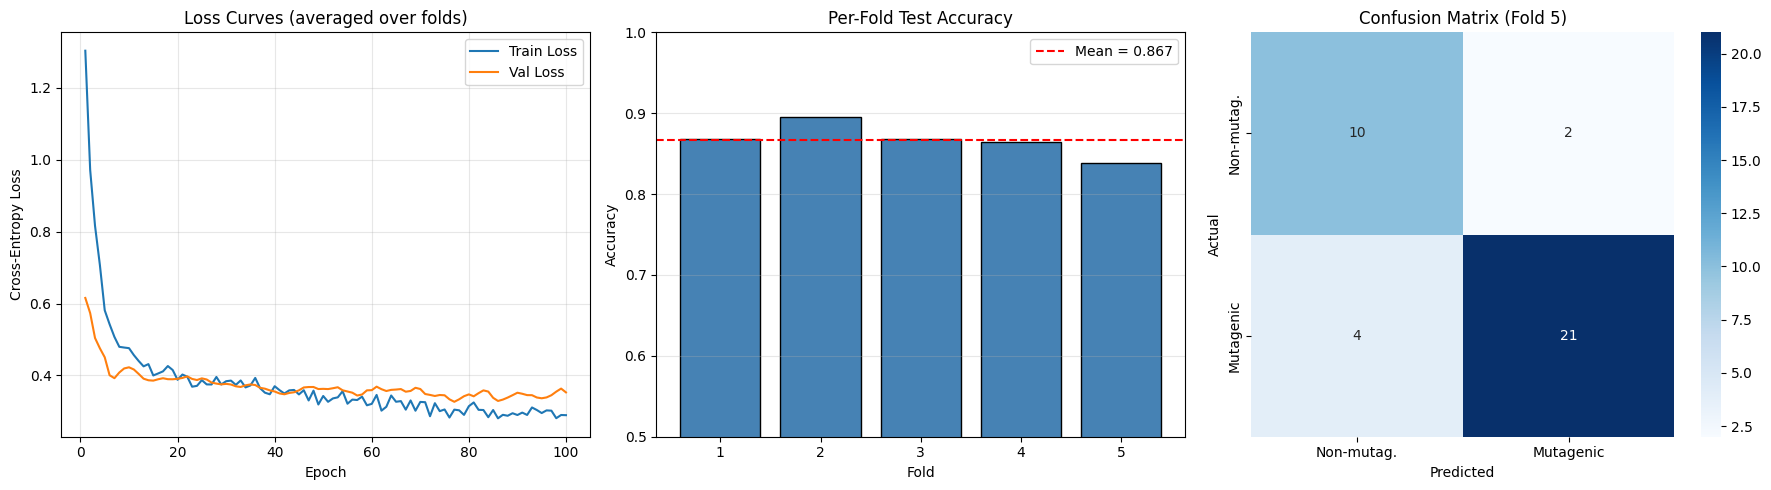


Classification Report (Fold 5):
               precision    recall  f1-score   support

Non-mutagenic       0.71      0.83      0.77        12
    Mutagenic       0.91      0.84      0.88        25

     accuracy                           0.84        37
    macro avg       0.81      0.84      0.82        37
 weighted avg       0.85      0.84      0.84        37



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

avg_train = np.mean(all_train_losses, axis=0)
avg_val = np.mean(all_val_losses, axis=0)
epochs_range = range(1, EPOCHS + 1)
axes[0].plot(epochs_range, avg_train, label="Train Loss")
axes[0].plot(epochs_range, avg_val, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Loss Curves (averaged over folds)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fold_accs = [r["acc"] for r in fold_results]
bars = axes[1].bar(range(1, K_FOLDS + 1), fold_accs, color="steelblue", edgecolor="black")
axes[1].axhline(mean_acc, color="red", linestyle="--", label=f"Mean = {mean_acc:.3f}")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Per-Fold Test Accuracy")
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

last = fold_results[-1]
cm = confusion_matrix(last["labels"], last["preds"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["Non-mutag.", "Mutagenic"],
            yticklabels=["Non-mutag.", "Mutagenic"])
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_title(f"Confusion Matrix (Fold {K_FOLDS})")

plt.tight_layout()
plt.savefig("mutag_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nClassification Report (Fold {K_FOLDS}):")
print(classification_report(last["labels"], last["preds"], target_names=["Non-mutagenic", "Mutagenic"]))

---

## Question 3

### Part (a): Computing 6-Membered Rings

We find all fundamental cycles in each molecular graph using `networkx.cycle_basis`, then count how many have exactly 6 atoms (i.e. benzene-like rings).

6-membered ring counts across the dataset:
  0 rings: 2 molecules
  1 rings: 48 molecules
  2 rings: 82 molecules
  3 rings: 38 molecules
  4 rings: 16 molecules
  5 rings: 1 molecules
  6 rings: 1 molecules


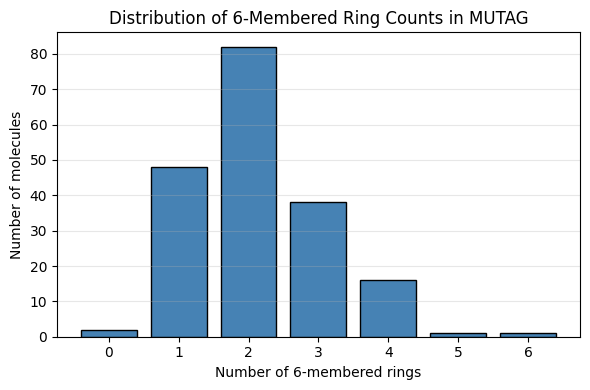

In [16]:
ring_counts = []
for i, data in enumerate(dataset):
    G = to_networkx(data, to_undirected=True)
    cycles = nx.cycle_basis(G)
    count = sum(1 for c in cycles if len(c) == 6)
    ring_counts.append(count)

ring_counts = np.array(ring_counts)

unique, freq = np.unique(ring_counts, return_counts=True)
print("6-membered ring counts across the dataset:")
for u, f in zip(unique, freq):
    print(f"  {u} rings: {f} molecules")

plt.figure(figsize=(6, 4))
plt.bar(unique, freq, color="steelblue", edgecolor="black")
plt.xlabel("Number of 6-membered rings")
plt.ylabel("Number of molecules")
plt.title("Distribution of 6-Membered Ring Counts in MUTAG")
plt.xticks(unique)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Part (b): Predicting Ring Counts with a GNN

**Why classification over regression?** The ring counts are small non-negative integers. Regression could predict fractional values (like 2.7 rings) which don't make physical sense. Cross-entropy also gives cleaner gradients for a handful of discrete classes.

**Grouping rare classes:** The raw counts go from 0 to 6, but classes 0, 5, 6 have only 1–2 samples each, far too few to learn from. So we group them into 4 bins: ≤1, 2, 3, ≥4 rings.

Same GIN architecture from Q2, output size = 4.

In [17]:
def bin_ring_count(c):
    if c <= 1:
        return 0
    elif c == 2:
        return 1
    elif c == 3:
        return 2
    else:
        return 3

BIN_NAMES = ["≤1", "2", "3", "≥4"]
num_ring_classes = len(BIN_NAMES)
binned = np.array([bin_ring_count(c) for c in ring_counts])

print(f"Binned into {num_ring_classes} classes:")
for i, name in enumerate(BIN_NAMES):
    print(f"  {name} rings: {(binned == i).sum()} molecules")

ring_dataset = []
for i, data in enumerate(dataset):
    d = data.clone()
    d.y = torch.tensor(binned[i], dtype=torch.long)
    ring_dataset.append(d)

torch.manual_seed(42)
perm = torch.randperm(len(ring_dataset))
split = int(0.8 * len(ring_dataset))
train_idx, test_idx = perm[:split], perm[split:]

train_data = [ring_dataset[i] for i in train_idx]
test_data = [ring_dataset[i] for i in test_idx]

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

print(f"\nTrain: {len(train_data)}, Test: {len(test_data)}")
train_labels = [ring_dataset[i].y.item() for i in train_idx]
test_labels = [ring_dataset[i].y.item() for i in test_idx]
print(f"Train class dist: {dict(zip(*np.unique(train_labels, return_counts=True)))}")
print(f"Test class dist:  {dict(zip(*np.unique(test_labels, return_counts=True)))}")

Binned into 4 classes:
  ≤1 rings: 50 molecules
  2 rings: 82 molecules
  3 rings: 38 molecules
  ≥4 rings: 18 molecules

Train: 150, Test: 38
Train class dist: {np.int64(0): np.int64(38), np.int64(1): np.int64(63), np.int64(2): np.int64(35), np.int64(3): np.int64(14)}
Test class dist:  {np.int64(0): np.int64(12), np.int64(1): np.int64(19), np.int64(2): np.int64(3), np.int64(3): np.int64(4)}


In [18]:
ring_model = GIN(
    in_channels=dataset.num_node_features,
    hidden_channels=64,
    out_channels=num_ring_classes,
    num_layers=3,
    dropout=0.5,
).to(device)

optimizer = torch.optim.Adam(ring_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=60, gamma=0.5)

train_losses, test_losses, test_accs = [], [], []

for epoch in range(1, 201):
    t_loss = train(ring_model, train_loader, optimizer)
    v_loss, v_acc, _, _ = evaluate(ring_model, test_loader)
    scheduler.step()
    train_losses.append(t_loss)
    test_losses.append(v_loss)
    test_accs.append(v_acc)
    if epoch % 40 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {t_loss:.4f} | Test Loss: {v_loss:.4f} | Test Acc: {v_acc:.4f}")

Epoch  40 | Train Loss: 0.8643 | Test Loss: 1.0813 | Test Acc: 0.6842
Epoch  80 | Train Loss: 0.8022 | Test Loss: 0.7837 | Test Acc: 0.8158
Epoch 120 | Train Loss: 0.6518 | Test Loss: 0.7461 | Test Acc: 0.7632
Epoch 160 | Train Loss: 0.6554 | Test Loss: 0.7170 | Test Acc: 0.7368
Epoch 200 | Train Loss: 0.6325 | Test Loss: 0.8514 | Test Acc: 0.8158


### Evaluation

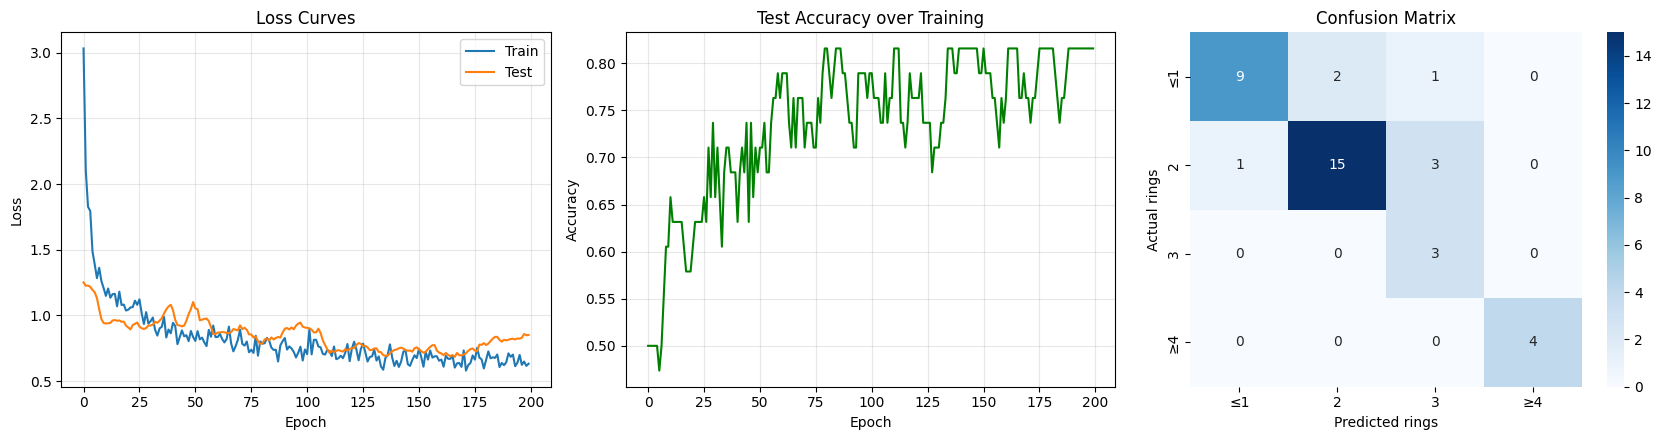


Test Accuracy: 0.8158

              precision    recall  f1-score   support

    ≤1 rings       0.90      0.75      0.82        12
     2 rings       0.88      0.79      0.83        19
     3 rings       0.43      1.00      0.60         3
    ≥4 rings       1.00      1.00      1.00         4

    accuracy                           0.82        38
   macro avg       0.80      0.88      0.81        38
weighted avg       0.86      0.82      0.83        38



In [19]:
_, final_acc, preds, true_labels = evaluate(ring_model, test_loader)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(train_losses, label="Train")
axes[0].plot(test_losses, label="Test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_accs, color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Test Accuracy over Training")
axes[1].grid(True, alpha=0.3)

cm = confusion_matrix(true_labels, preds, labels=list(range(num_ring_classes)))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=BIN_NAMES, yticklabels=BIN_NAMES)
axes[2].set_xlabel("Predicted rings")
axes[2].set_ylabel("Actual rings")
axes[2].set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig("mutag_rings_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTest Accuracy: {final_acc:.4f}\n")
print(classification_report(
    true_labels, preds,
    labels=list(range(num_ring_classes)),
    target_names=[f"{n} rings" for n in BIN_NAMES],
    zero_division=0,
))